In [20]:
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import requests
import matplotlib.pyplot as plt

# **ESG BRAIN**

In [4]:
# 1. Collecting ESG sources - sources must be time stamped for timeseries comparison

# individual ESG rating - NSE
url_esg_rating = "https://www.nse-esgrating.com/esg-ratings"

# BRSR - Business Resposibility and Sustainable Reporting - SEBI Body that provides
#quantifiable outputs for Indian companies regarding their ESG compliance

# ESG News
url_esg_news = "https://esgnews.com/category/esg-india/"
response = requests.get(url_esg_news)
response


<Response [200]>

In [30]:
# Scraping Data
# storing architecture - list of objects
# news =[
#     {"news":news},
#     {"news":news},
#     {"news":news},

# ]
news_list = []
soup = BeautifulSoup(response.content, 'html.parser')

# capture wholw post card
posts = soup.find_all('div', class_='tt-post')
for post in posts:
    news_dict = {}
    news_dict['title'] = post.find('a', class_='tt-post-title').text
    timestamp = post.find('span', class_='tt-post-date')
    # Because some timestamps hade "None" value
    if timestamp:
        news_dict['timestamp'] = timestamp.text
        news_dict['timestamp'] = pd.to_datetime(news_dict['timestamp'], dayfirst=True)
    else:
        news_dict['timestamp'] = None
    news_list.append(news_dict)
news_list


[{'title': 'Why Sustainability Platforms Are Partnering on XBRL Instead of Building It',
  'timestamp': Timestamp('2026-01-29 00:00:00')},
 {'title': 'Bloomberg Integrates Calyx Global Carbon Credit Ratings Into Terminal To Strengthen Carbon Market Transparency',
  'timestamp': Timestamp('2026-01-29 00:00:00')},
 {'title': 'BMI Expands ESG Country Risk Analytics With Physical Climate Scenarios To 2050',
  'timestamp': Timestamp('2026-01-29 00:00:00')},
 {'title': 'Puro.earth Launches On Demand Issuance Service to Accelerate CDR Liquidity, Revenue Cycles',
  'timestamp': Timestamp('2026-01-28 00:00:00')},
 {'title': 'Why Sustainability Platforms Are Partnering on XBRL Instead of Building It',
  'timestamp': Timestamp('2026-01-29 00:00:00')},
 {'title': 'Mercedes AMG Petronas F1 Accelerates Logistics, Materials Innovation to Cut Emissions in 2025 Season',
  'timestamp': Timestamp('2026-01-21 00:00:00')},
 {'title': 'eBay Targets Net Zero by 2045 and Expands SBTi Validated Climate Plan',


In [ ]:
# Dataframe format - Headline, Description, Timestamp
data = pd.DataFrame(news_list)
data
data.to_csv('ESG_articles.csv')

In [ ]:
# Text prprocessing
# 1. stopwords
# 2. lemmetization/stemming
# 3. keep timestamp for cluster of news for a certain time

# **TIME SERIES BRAIN**

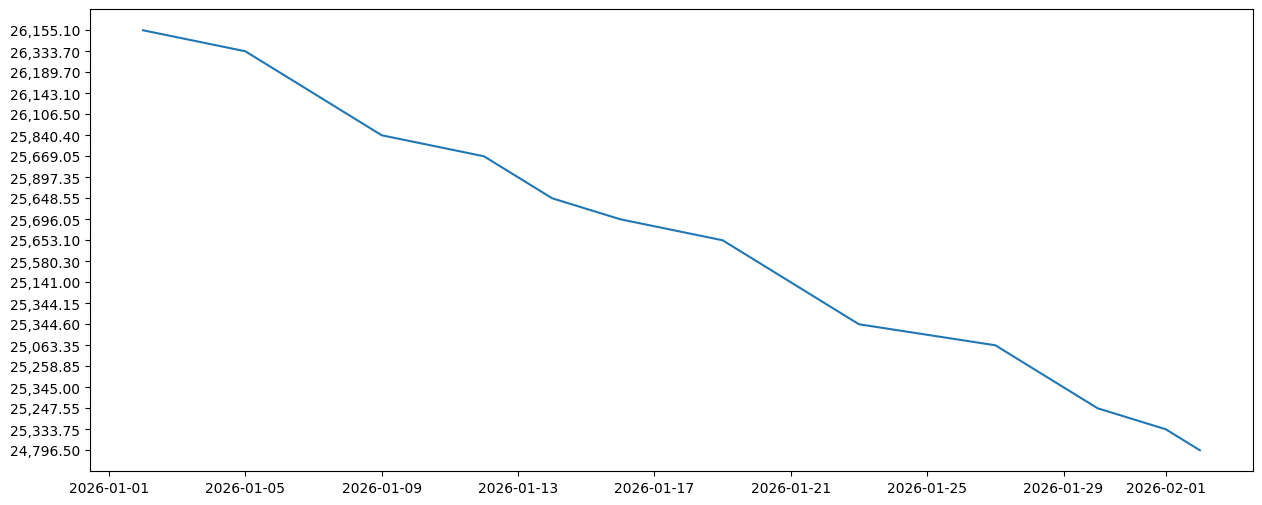

In [29]:
# Loading Nifty50 Historical Data
data_nifty = pd.read_csv('nifty_50.csv')
df_nifty = pd.DataFrame(data_nifty)

df_nifty["Date"] = pd.to_datetime(df_nifty['Date'], dayfirst=True)
plt.figure(figsize=(15,6))
plt.plot(df_nifty["Date"], df_nifty["Open"],  label="Test Graph")

In [ ]:
# Time Series Visualisation
import matplotlib.pyplot as plt


# **FUSION LOGIC**